## Argimiro Arratia @2025 Computational Finance
## PyLab3_1 — Causality of financial time series (Granger)
### 1. Introduction
We illustrate Granger causality on the classical USMoney dataset (the C. Sims experiment: does money cause GNP?), and then apply the same machinery to monthly SP500 returns and a proxy of volatility.

In R the script uses `lmtest::grangertest`, `vars::VARselect`, `vars::VAR` and `bruceR::granger_causality`. In Python we use `statsmodels.tsa.stattools.grangercausalitytests` and `statsmodels.tsa.api.VAR`.


### 2. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Granger causality and VAR (statsmodels equivalents of lmtest/vars/bruceR)
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR

### 3. The USMoney dataset
A quarterly multiple time series 1950–1985 with three variables:
- `gnp`     — nominal Gross National Product,
- `m1`      — measure of money stock,
- `deflator`— implicit price deflator for GNP (a measure of inflation).

This dataset is exported from R's `AER` package; we read the CSV that ships with these notebooks (`data/USMoney.csv`).


In [3]:
USMoney = pd.read_csv('USMoney.csv', parse_dates=['date'], index_col='date')
print(USMoney.columns.tolist())
USMoney.head()

['gnp', 'm1', 'deflator']


,gnp,m1,deflator
date,,,
1950-01-01,267.6,110.20,56.04
1950-04-01,277.1,111.75,56.21
1950-07-01,294.8,112.95,56.41
1950-10-01,306.3,113.93,56.67
1951-01-01,320.4,115.08,56.77


### 4. Is correlation a motive for causation? See plots and corr.

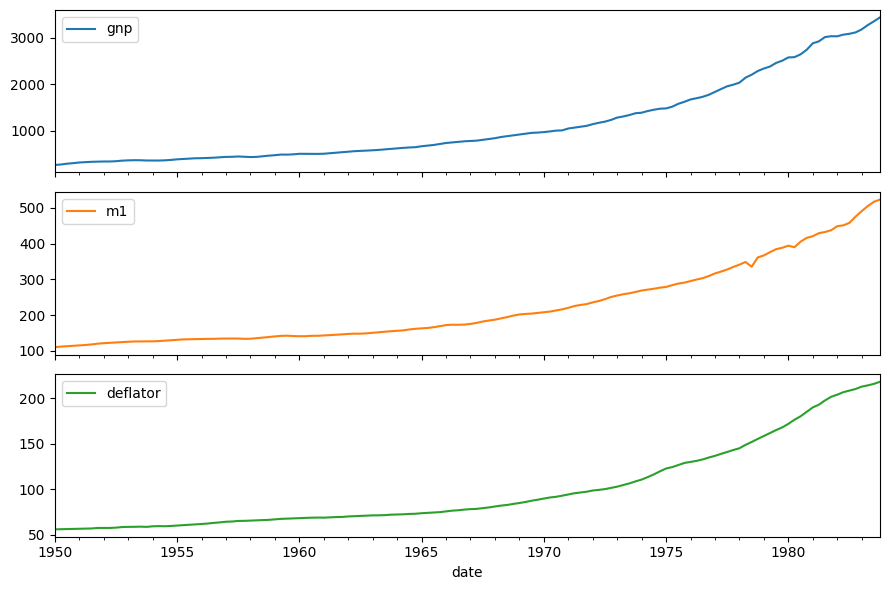

,gnp,m1,deflator
gnp,1.000000,0.997575,0.998638
m1,0.997575,1.000000,0.995935
deflator,0.998638,0.995935,1.000000


In [4]:
USMoney.plot(subplots=True, figsize=(9, 6))
plt.tight_layout()
plt.show()

USMoney.corr()

### 5. C. Sims experiment: does money cause GNP (or GNP cause money)?
In R: `grangertest(gnp ~ m1, order=3, data=USMoney)`.

`statsmodels.grangercausalitytests(data, maxlag)` tests whether the **second** column Granger-causes the **first**. So to test "m1 → gnp" we pass `[gnp, m1]`.


In [5]:
# To know if money (m1) causes gnp:  m1 -> gnp  (test 'gnp ~ m1', order 3)
print('--- m1 -> gnp, lag=3 ---')
res_m1_gnp = grangercausalitytests(USMoney[['gnp', 'm1']], maxlag=3, verbose=True)

--- m1 -> gnp, lag=3 ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=12.6091 , p=0.0005  , df_denom=132, df_num=1
ssr based chi2 test:   chi2=12.8957 , p=0.0003  , df=1
likelihood ratio test: chi2=12.3164 , p=0.0004  , df=1
parameter F test:         F=12.6091 , p=0.0005  , df_denom=132, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.3405  , p=0.0024  , df_denom=129, df_num=2
ssr based chi2 test:   chi2=13.1725 , p=0.0014  , df=2
likelihood ratio test: chi2=12.5646 , p=0.0019  , df=2
parameter F test:         F=6.3405  , p=0.0024  , df_denom=129, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=6.0479  , p=0.0007  , df_denom=126, df_num=3
ssr based chi2 test:   chi2=19.1517 , p=0.0003  , df=3
likelihood ratio test: chi2=17.8924 , p=0.0005  , df=3
parameter F test:         F=6.0479  , p=0.0007  , df_denom=126, df_num=3


/Applications/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


first variable is effect, second one is cause


In [6]:
# To know if gnp causes money: gnp -> m1
print('--- gnp -> m1, lag=3 ---')
res_gnp_m1 = grangercausalitytests(USMoney[['m1', 'gnp']], maxlag=3, verbose=True)

--- gnp -> m1, lag=3 ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.2006  , p=0.2752  , df_denom=132, df_num=1
ssr based chi2 test:   chi2=1.2279  , p=0.2678  , df=1
likelihood ratio test: chi2=1.2224  , p=0.2689  , df=1
parameter F test:         F=1.2006  , p=0.2752  , df_denom=132, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.3275  , p=0.0390  , df_denom=129, df_num=2
ssr based chi2 test:   chi2=6.9129  , p=0.0315  , df=2
likelihood ratio test: chi2=6.7405  , p=0.0344  , df=2
parameter F test:         F=3.3275  , p=0.0390  , df_denom=129, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.7340  , p=0.0465  , df_denom=126, df_num=3
ssr based chi2 test:   chi2=8.6577  , p=0.0342  , df=3
likelihood ratio test: chi2=8.3875  , p=0.0386  , df=3
parameter F test:         F=2.7340  , p=0.0465  , df_denom=126, df_num=3


/Applications/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [7]:
# To only get the p-value (analogue of GT$`Pr(>F)`[2] in R)
# statsmodels returns dict keyed by lag; each value is a tuple where
# index 0 is a dict of test statistics, e.g. 'ssr_ftest' -> (F, p, df_denom, df_num)
pval_m1_gnp_lag3 = res_m1_gnp[3][0]['ssr_ftest'][1]
print('p-value (m1 -> gnp, lag 3):', pval_m1_gnp_lag3)

p-value (m1 -> gnp, lag 3): 0.0007010960334229553


### 6. Estimating the optimal lag with VARselect
In R: `VARselect(USMoney, lag.max=10, type='none')$selection['HQ(n)']`. In Python the analogue is `VAR.select_order(maxlags=10).hqic`.


For homework use AIC

In [8]:
# R: VARselect(USMoney, lag.max=10, type='none')
# 'type=none' means a VAR with NO deterministic terms (no constant, no trend).
# In statsmodels we pass trend='n'.
model = VAR(USMoney)
sel = model.select_order(maxlags=10, trend='n')
# NOTE: sel.summary() has a known statsmodels bug when a criterion picks the
# maximum lag (IndexError in LagOrderResults.summary). Print the selected
# orders dict directly instead.
print(sel.selected_orders)
p = int(sel.hqic)
p = max(p, 1)
print('chosen lag p =', p)

{'aic': 10, 'bic': 2, 'hqic': 4, 'fpe': 9}
chosen lag p = 4


/Applications/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [9]:
# m1 -> gnp at lag p
h = p
res = grangercausalitytests(USMoney[['gnp', 'm1']], maxlag=h, verbose=False)
print('m1 -> gnp p-value at lag', h, ':', res[h][0]['ssr_ftest'][1])

# gnp -> m1 at lag p
res = grangercausalitytests(USMoney[['m1', 'gnp']], maxlag=h, verbose=False)
print('gnp -> m1 p-value at lag', h, ':', res[h][0]['ssr_ftest'][1])

m1 -> gnp p-value at lag 4 : 0.0028348228806143964
gnp -> m1 p-value at lag 4 : 0.006543894668306333


/Applications/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Applications/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Try values of `lag.max` from 8–15. What do you observe?

### 7. Multivariate Granger causality with VAR
The R script uses `bruceR::granger_causality(VAR(USMoney, p))` to perform all multivariate Granger tests at once. The closest analogue in `statsmodels` is `VARResults.test_causality(caused, causing, kind='f')`.


In [10]:
# R: VAR(USMoney, p)  -- type defaults to 'const' in vars::VAR(),
# so the fitted VAR DOES include a constant term, even though VARselect
# above used type='none'. We mirror that asymmetry exactly.
var_fit = VAR(USMoney).fit(p, trend='c')
print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 04, May, 2026
Time:                     12:54:45
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    6.51655
Nobs:                     132.000    HQIC:                   6.01092
Log likelihood:          -896.777    FPE:                    289.089
AIC:                      5.66481    Det(Omega_mle):         218.097
--------------------------------------------------------------------
Results for equation gnp
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const             -48.459273        35.291403           -1.373           0.170
L1.gnp              1.150476         0.112401           10.235           0.000
L1.m1               1.663730         0.525938            3.163        

/Applications/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [11]:
# All pairwise causality tests within the fitted VAR
variables = USMoney.columns.tolist()
rows = []
for caused in variables:
    for causing in variables:
        if caused == causing:
            continue
        t = var_fit.test_causality(caused=caused, causing=causing, kind='f')
        rows.append({'causing': causing, 'caused': caused,
                     'F': t.test_statistic, 'p.F': t.pvalue, 'df': t.df})
GC = pd.DataFrame(rows)
GC

,causing,caused,F,p.F,df
0,m1,gnp,4.349175,0.001904,"(4, 357)"
1,deflator,gnp,0.640807,0.633710,"(4, 357)"
2,gnp,m1,0.578942,0.678086,"(4, 357)"
3,deflator,m1,5.399640,0.000313,"(4, 357)"
4,gnp,deflator,2.143071,0.075050,"(4, 357)"
5,m1,deflator,2.156176,0.073506,"(4, 357)"


### 8. Causality on monthly SP500 returns and squared returns
Monthly SP500 readings. The R script uses `../data/SP500.rds`. We use the equivalent monthly SP500 series from `data/SP500_shiller.csv`.


Use EWMA for volatility estimator

In [12]:
sp500m = pd.read_csv('data/SP500_shiller.csv', parse_dates=['Date'], index_col='Date')[['SP500']]
print(sp500m.head())
print(sp500m.tail())

FileNotFoundError: [Errno 2] No such file or directory: 'data/SP500_shiller.csv'

In [ ]:
# Simple monthly returns; remove the first NA
sp500R = sp500m['SP500'].pct_change().dropna()
sp500R.name = 'sp500R'

# Sum of squared returns (proxy of volatility)
spRc2 = (sp500R ** 2).cumsum().dropna()
spRc2.name = 'spR2cum'

data = pd.concat([sp500R, spRc2], axis=1).dropna()
data.columns = ['sp500R', 'spR2cum']
data.head()

In [ ]:
# R: p <- VARselect(data, lag.max=15, type='none')$selection['HQ(n)']
#    GC <- granger_causality(VAR(data, p))   # default type='const'
sel = VAR(data).select_order(maxlags=15, trend='n')
print(sel.selected_orders)   # avoid sel.summary() — known statsmodels IndexError
p = max(int(sel.hqic), 1)
print('chosen lag p =', p)
var_fit2 = VAR(data).fit(p, trend='c')

In [ ]:
# All pairwise Granger causality tests within the VAR
variables = data.columns.tolist()
rows = []
for caused in variables:
    for causing in variables:
        if caused == causing:
            continue
        t = var_fit2.test_causality(caused=caused, causing=causing, kind='f')
        rows.append({'Causality': f'{causing} => {caused}',
                     'F': t.test_statistic, 'p.F': t.pvalue})
GC = pd.DataFrame(rows)
GC

In [ ]:
# Grab significant causalities at level alpha
alpha = 0.05
signif = GC[GC['p.F'] < alpha]['Causality']
print(signif.tolist())

**Exercises**
- Run the test for all lags `h = 1,...,p` (use a loop).
- Consider different sample periods / different epochs.
